# MARITIME WORLD - Working with Time Series
   - Dataset: "https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst"
   - Data dictionary: https://coast.noaa.gov/data/marinecadastre/ais/data-dictionary.pdf

## Loading Dataframe

In [ ]:
import pandas as pd
url = "https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst"
df=pd.read_csv(url)
print(df.shape)           # print to know no of columns & rows in df
print()
print(df.dtypes)          # print datatypes of columns in df
print()
print(df.index)           # checking the by-default index in df
print()
print(df.index.name)      # checking label assigned to index itself

(5929631, 17)
5929631

mmsi                int64
base_date_time     object
longitude         float64
latitude          float64
sog               float64
cog               float64
heading           float64
vessel_name        object
imo                object
call_sign          object
vessel_type       float64
status            float64
length            float64
width             float64
draft             float64
cargo             float64
transceiver        object
dtype: object

RangeIndex(start=0, stop=5929631, step=1)

None


## Setting the index

In [ ]:
# To index the "base_date_time" column:
# - first convert the current column datatype 'object' into 'timestamps' datatype d: (pd.to_datetime()
# - then apply it as the index: df.set_index() to move that column to the index position


df["base_date_time"] = pd.to_datetime(df["base_date_time"])
df.set_index("base_date_time", inplace=True)


In [ ]:
# Checking if 'base_date_time' column has been indexed
print(df.index)
print()
print(df.index.name)      # checking label assigned to new index itself

DatetimeIndex(['2025-01-08 00:00:00', '2025-01-08 00:00:00',
               '2025-01-08 00:00:01', '2025-01-08 00:00:10',
               '2025-01-08 00:00:09', '2025-01-08 00:00:10',
               '2025-01-08 00:00:19', '2025-01-08 00:00:20',
               '2025-01-08 00:00:05', '2025-01-08 00:00:04',
               ...
               '2025-01-08 23:21:37', '2025-01-08 23:26:18',
               '2025-01-08 23:36:28', '2025-01-08 23:39:28',
               '2025-01-08 18:01:42', '2025-01-08 18:58:42',
               '2025-01-08 19:49:42', '2025-01-08 21:13:42',
               '2025-01-08 22:07:42', '2025-01-08 23:34:42'],
              dtype='datetime64[ns]', name='base_date_time', length=5929631, freq=None)

base_date_time


# Cleaning the data

In [ ]:
# Checking number of NaN values per column

df.isnull().sum()


,0
mmsi,0
longitude,0
latitude,0
sog,12540
cog,1069760
heading,3000096
vessel_name,17112
imo,3563659
call_sign,730997
vessel_type,42576


In [ ]:
# 1. REMOVE ROWS WHERE value of 'sog' COLUMN IS "Nan"
#  ***** df.dropna(subset=['SOG'], inplace=True)
#  ***** Optional: Verify there are no nulls left in SOG
#  print(f"Remaining nulls in SOG: {df['SOG'].isnull().sum()}")

df.dropna(subset=['sog'], inplace=True)

# To check number of null values under "sog" column after removing
df.isnull().sum()    #It shows number of number of null values under "sog" = 0 after removing, IT WORKED!

print(df.isnull())       # print to check if any values in 'sog' column has still "NaN" values left
print()
print(f"Remaining nulls in 'sog' column: {df['sog'].isnull().sum()}")

                      mmsi  longitude  latitude    sog    cog  heading  \
base_date_time                                                           
2025-01-08 00:00:00  False      False     False  False  False     True   
2025-01-08 00:00:00  False      False     False  False  False     True   
2025-01-08 00:00:01  False      False     False  False  False    False   
2025-01-08 00:00:10  False      False     False  False  False     True   
2025-01-08 00:00:09  False      False     False  False  False     True   
...                    ...        ...       ...    ...    ...      ...   
2025-01-08 18:58:42  False      False     False  False   True    False   
2025-01-08 19:49:42  False      False     False  False   True    False   
2025-01-08 21:13:42  False      False     False  False   True    False   
2025-01-08 22:07:42  False      False     False  False   True    False   
2025-01-08 23:34:42  False      False     False  False   True    False   

                     vessel_name    i

In [ ]:
# 2. Check to see how many rows were removed

print(f"Rows removed: {len(df)}")


Rows removed: 5917091


# First Analysis:
### - When are boats out?
### - Display a line graph where your x-axis is the hour of the day, and the y-axis is the number of unique vessels out at that hour.
Hint: the MMSI column is a great way to identity a unique vessel. What time (UTC) saw the most boats out on the water? And the least? Does this track with what you could expect?

In [ ]:
import matplotlib.pyplot as plt

#  1. Group by the hour of the index and count unique 'mmsi' values
#  'mmsi' column is a great way to identity a unique vessels. It groups all records by their specific hour and counts
#  & how many distinct 'mmsi' numbers appear in that group.     * mmsi = Maritime Mobile Service Identity (unique 9-digit number to identiry vessels)

df.groupby(df.index.hour)['mmsi'].nunique()

,mmsi
base_date_time,
0,12641
1,12502
2,12486
3,12482
4,12452
5,12481
6,12454
7,12415
8,12316


In [ ]:
# new variable "hourly_unique_vessels" is assigned values of unique 'mmsi'

hourly_unique_vessels = df.groupby(df.index.hour)['mmsi'].nunique()
hourly_unique_vessels

,mmsi
base_date_time,
0,12641
1,12502
2,12486
3,12482
4,12452
5,12481
6,12454
7,12415
8,12316


<Axes: title={'center': 'WHEN ARE BOATS OUT?'}, xlabel='hour of the day', ylabel='No of unique vessels'>

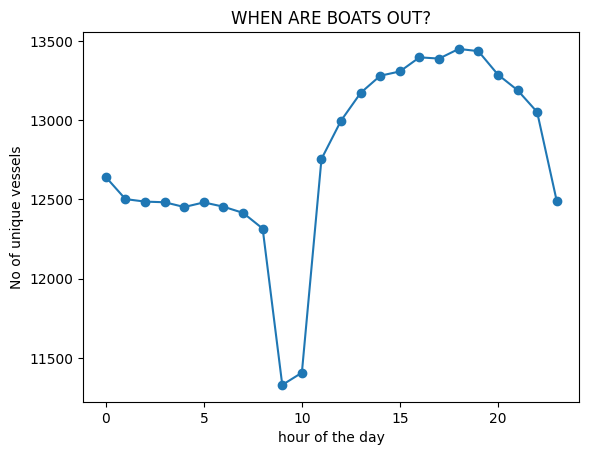

In [ ]:
# 2. Plotting the results with 'LINE GRAPH'
#    Created LABELS for X-axis as: "hour of the day", Y-axis as: "No of unique vessels, & title as: "WHEN ARE BOATS OUT?"



hourly_unique_vessels.plot(kind='line', xlabel='hour of the day', ylabel='No of unique vessels', title='WHEN ARE BOATS OUT?', marker='o')

# marker='o': Adds clear data points to each hour on the line, making the peaks and troughs easier to identify visually

# Second Analysis:
#### -  Let's look at a specific boat, the Henry Hudson (MMSI: 366651000). The owner of the boat has asked us how long the boat engines were active for that day. To get to this, you must:
 a) Figure out when the boat was "accelerating". Create a column called "acceleration", which is going to be the difference between each "sog". Hints: to achieve this, use the "diff()" function on your column. Be sure that your index is sorted, meaning the rows are sorted by time (.sort_index() is very helpful for this)

 b) Create a duration column, which is the difference between each "base_date_time"

 c) Once you have a column "acceleration" and "duration", we can assume that the boat engines were active if the "acceleration" is greater than 0. Filter your dataframe to only have rows where the acceleration is positive.

 d) Sum up the "duration" column to see how long the engines were active for that day. This will allow us to answer the boat captain

In [ ]:
# 1. Filter for the specific vessel and sort by time & our index is already set to 'base_date_time'

df[df['mmsi'] == 366651000].sort_index()

# new variable 'vessel_df' is created to assign sorted index column "base_date_time"

vessel_df = df[df['mmsi'] == 366651000].sort_index()

In [ ]:
# A new column called 'acceleration' is created, which is going to be the (difference between each 'sog')

# a) To calculate 'acceleration' column:

vessel_df['sog'].diff()                                 # .diff() function is called on our column 'sog'
vessel_df['acceleration'] = vessel_df['sog'].diff()     # 'acceleration' column is assigned the difference between each 'sog'

# b) Also, a new column 'duration' is created which is going to be the (difference between each timestamp)
# since 'base_date_time' column is the index, we use index.to_series() to find the difference

vessel_df.index.to_series().diff()

vessel_df['duration'] = vessel_df.index.to_series().diff()   # 'duration' column is assigned the difference between each 'timestamp'

# c) Filter for rows where acceleration is positive
# We drop the first row because .diff() results in a NaN for the first entry

vessel_df[vessel_df['acceleration'] > 0].dropna(subset=['duration'])

# new variable 'active_engine' is created and assigned where only vesel acceleration is greater than "0" only. Else, DROP an inactive vessel
active_engines = vessel_df[vessel_df['acceleration'] > 0].dropna(subset=['duration'])

# d) Sum up the duration column to see how long the engines were active for that day
active_engines['duration'].sum()

# a new variable 'total_active_time' is created and assigned the result of sum of the duration columns to see the total duration of active engine for that day

total_active_time = active_engines['duration'].sum()
total_active_time

print(f"Total engine active duration for the Henry Hudson: {total_active_time}")

Total engine active duration for the Henry Hudson: 0 days 08:03:24
